# Energy Indicators, Advanced Tutorial

Compares two contrasting real sites, Tico (Villar de los Navarros,
Zaragoza, Spain, onshore) and Moray East (Scotland, offshore,
matching its real installed Vestas V164-9.5MW turbines), for Wind
indicators, and uses Zaragoza (real nearby city) and Fuendetodos
(real nearby solar farm) for Demand and Solar. Data: January 2035
(both sites, all indicators) and July 2035 (Solar's winter/summer
comparison). SSP3-7.0 scenario, retrieved via
`data_retrieval_earthkit.ipynb`. These files are already provided 
in the repository, this notebook doesn't require DESP credentials itself.

All data is at `resolution="standard"` (HEALPix H128, ~50 km native
cells), so each site's data is the nearest available cell, not its
exact coordinate.


Tico's real installed turbines (Siemens-Gamesa SG 5.0-132, SG
3.4-132) are approximated to be IEC Class III, not a genuine match.

Fuendetodos and Tico are about 20 km apart, close enough that Tico's
wind is reused as a stand-in for both the winter and summer PV
potential calculations, since Fuendetodos itself has no wind
retrieval of its own.

## Setup

In [6]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from energy_indicators.core import wind_speed, convert_temperature
from energy_indicators.utils import load_turbines
from energy_indicators.wind import (
    capacity_factor,
    high_wind_events,
    low_wind_events,
    wind_speed_histogram_1d,
    capacity_factor_histogram_1d,
    annual_energy_production_wind,
)
from energy_indicators.demand import cooling_degree_days, heating_degree_days
from energy_indicators.solar import pv_pot

data_path = "data/"
out_path = "./tutorial_output/advanced/"
os.makedirs(out_path, exist_ok=True)

colors = {"moray_east": "blue", "tico": "green"}

sites = {
    "moray_east": {"name": "Moray East", "iec_class": "S", "type": "offshore"},
    "tico": {"name": "Tico", "iec_class": "III", "type": "onshore"},
}


## Turbine specifications

Pulled directly from the package rather than hardcoded.

In [7]:
turbine_specs = {t["turbine_model"]: t for t in load_turbines()}
class_to_model = {"III": "Vestas V110", "S": "Vestas V164"}

for key, s in sites.items():
    spec = turbine_specs[class_to_model[s["iec_class"]]]
    s["rated_power"] = spec["rated_power"] / 1000  # kW -> MW
    s["cut_in_speed"] = spec["cut_in_speed"]
    s["rated_speed"] = spec["rated_speed"]
    s["cut_out_speed"] = spec["cut_out_speed"]
    print(f"{s['name']} (Class {s['iec_class']}, {spec['turbine_model']}): "
          f"{s['rated_power']} MW, cut-in={s['cut_in_speed']} m/s, "
          f"rated={s['rated_speed']} m/s, cut-out={s['cut_out_speed']} m/s")


Moray East (Class S, Vestas V164): 9.5 MW, cut-in=3.5 m/s, rated=14.0 m/s, cut-out=25.0 m/s
Tico (Class III, Vestas V110): 2.0 MW, cut-in=4.0 m/s, rated=12.0 m/s, cut-out=20.0 m/s


Retrieved point time series have shape `(time,)` (wind also carries
a leftover, size-1 `level` dimension). Every `energy_indicators`
function expects `(time, lat, lon)`, even for a single point.

In [8]:
def as_grid(da, lat, lon):
    da = da.squeeze()
    return da.expand_dims({"lat": [lat], "lon": [lon]}).transpose("time", "lat", "lon")


A single point has no meaningful land-sea mask to apply. The
onshore/offshore contrast here comes from choosing genuinely
different sites, not spatial masking.

## 1. Wind

### Wind Producing Regimes

Each site's `high_wind_events`/`low_wind_events` thresholds use its
own real turbine's cut-in/cut-out speeds, so the counts genuinely
reflect that turbine's operating envelope.

In [9]:
wind_speeds = {}
cf_data = {}

for key, s in sites.items():
    wind = xr.open_dataset(data_path + f"{key}_wind_203501.nc")
    lat, lon = float(wind["lat"]), float(wind["lon"])
    u = as_grid(wind["u"], lat, lon)
    v = as_grid(wind["v"], lat, lon)
    ws = wind_speed(u, v)
    wind_speeds[key] = ws
    s["lat"], s["lon"] = lat, lon

    hwe = high_wind_events(ws, threshold=s["cut_out_speed"])
    lwe = low_wind_events(ws, threshold=s["cut_in_speed"])
    s["hwe"] = int(hwe["hwe"].values.squeeze())
    s["lwe"] = int(lwe["lwe"].values.squeeze())
    s["producing"] = ws.sizes["time"] - s["hwe"] - s["lwe"]

    cf = capacity_factor(ws, iec_class=s["iec_class"])
    cf_data[key] = cf[f"cf_{s['iec_class'].lower()}"]

    print(f"{s['name']} (Class {s['iec_class']}, cut-in={s['cut_in_speed']}, "
          f"cut-out={s['cut_out_speed']}): "
          f"low-wind={s['lwe']}h, high-wind={s['hwe']}h, "
          f"producing={s['producing']}h out of {ws.sizes['time']}h total")


Moray East (Class S, cut-in=3.5, cut-out=25.0): low-wind=16h, high-wind=0h, producing=728h out of 744h total
Tico (Class III, cut-in=4.0, cut-out=20.0): low-wind=397h, high-wind=0h, producing=347h out of 744h total


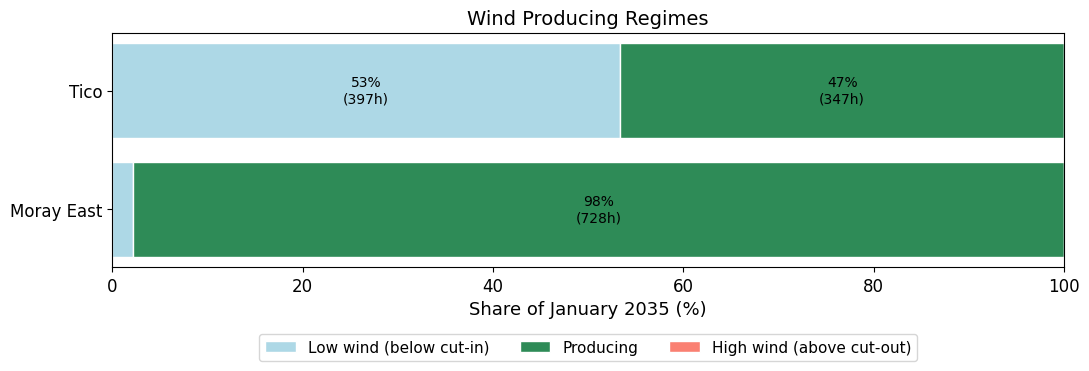

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))

labels = [s["name"] for s in sites.values()]
lwe_pct = [100 * s["lwe"] / (s["lwe"] + s["producing"] + s["hwe"]) for s in sites.values()]
producing_pct = [100 * s["producing"] / (s["lwe"] + s["producing"] + s["hwe"]) for s in sites.values()]
hwe_pct = [100 * s["hwe"] / (s["lwe"] + s["producing"] + s["hwe"]) for s in sites.values()]

segments = [
    ("Low wind (below cut-in)", lwe_pct, [s["lwe"] for s in sites.values()], "lightblue"),
    ("Producing", producing_pct, [s["producing"] for s in sites.values()], "seagreen"),
    ("High wind (above cut-out)", hwe_pct, [s["hwe"] for s in sites.values()], "salmon"),
]

left = np.zeros(len(labels))
for name, pct, hours, color in segments:
    bars = ax.barh(labels, pct, left=left, label=name, color=color, edgecolor="white")
    for bar, p, h in zip(bars, pct, hours):
        if p > 3:  # skip labels on segments too thin to read
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                     f"{p:.0f}%\n({h}h)", ha="center", va="center", fontsize=10)
    left += np.array(pct)

ax.set_xlabel("Share of January 2035 (%)", fontsize=13)
ax.set_xlim(0, 100)
ax.tick_params(labelsize=12)
ax.set_title("Wind Producing Regimes", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=11)
plt.tight_layout()
plt.savefig(out_path + "wind_producing_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

### Capacity Factor

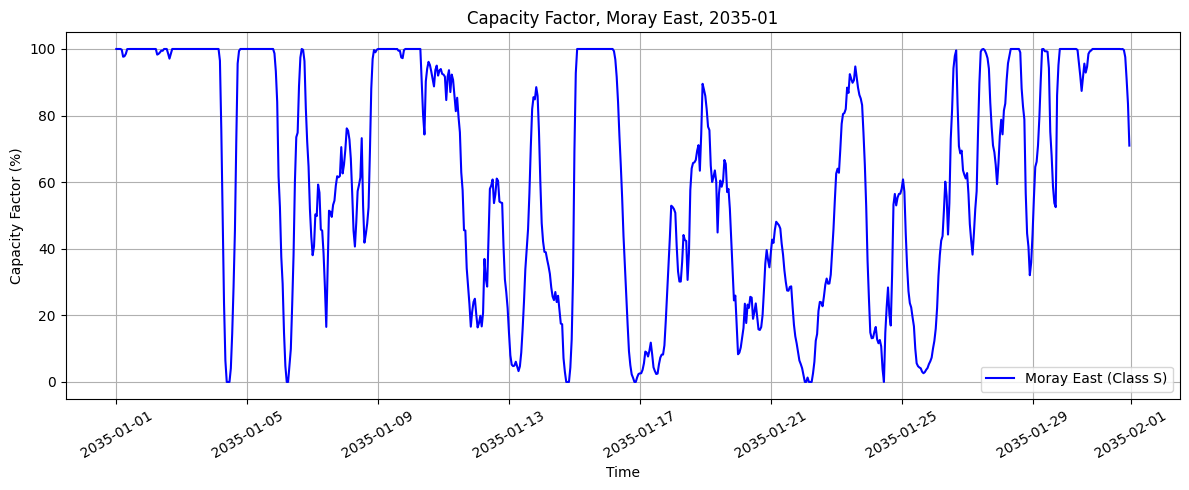

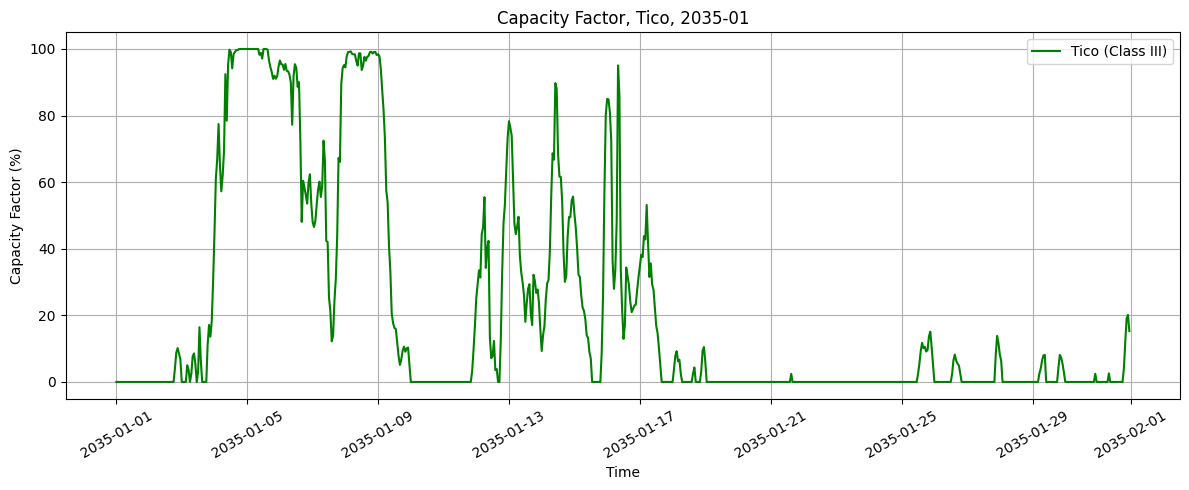

In [12]:
for key, s in sites.items():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(cf_data[key]["time"], cf_data[key].squeeze() * 100,
             label=f"{s['name']} (Class {s['iec_class']})", color=colors[key])
    ax.set_xlabel("Time"); ax.set_ylabel("Capacity Factor (%)")
    ax.set_title(f"Capacity Factor, {s['name']}, 2035-01")
    ax.legend(); ax.grid(True)
    plt.xticks(rotation=30); plt.tight_layout()
    plt.savefig(out_path + f"capacity_factor_{key}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Wind Speed and Capacity Factor Histograms

30 bins, normalised to a frequency density, fixed physically
meaningful axis ranges.

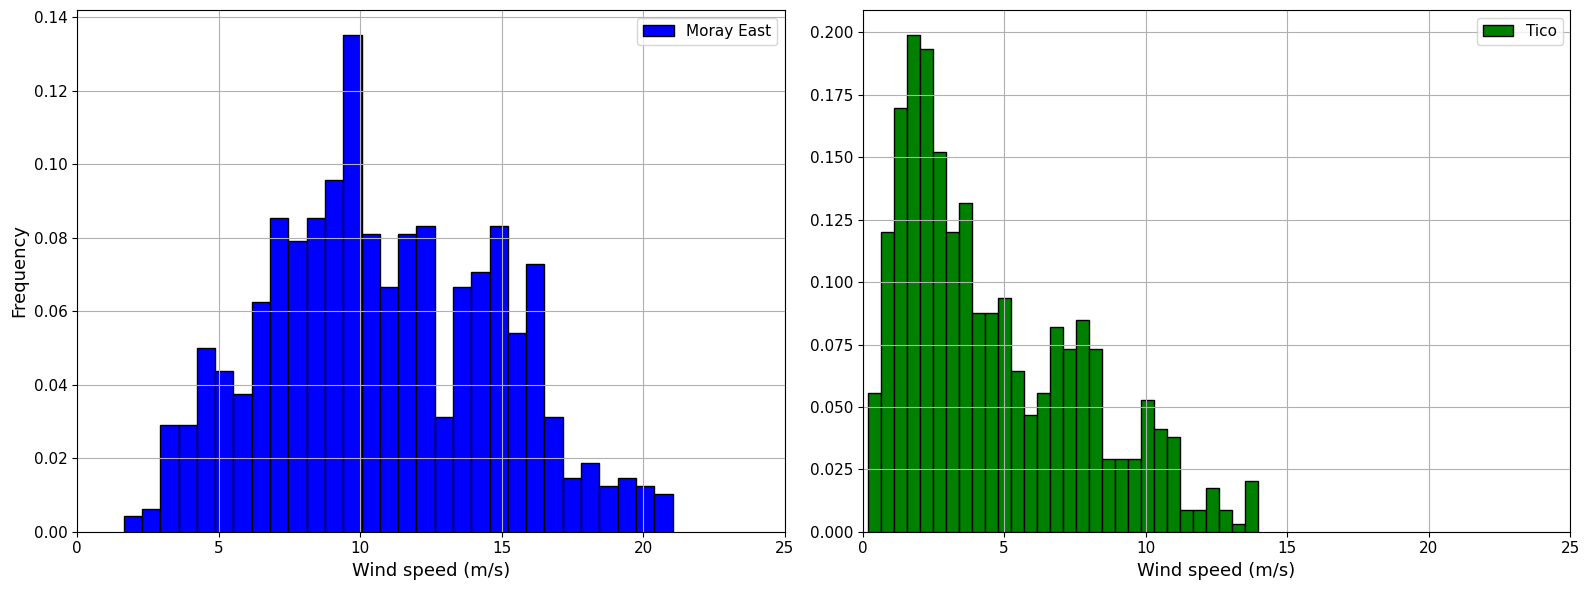

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (key, s) in zip(axes, sites.items()):
    counts, edges = wind_speed_histogram_1d(wind_speeds[key], 30, s["lon"], s["lat"])
    ax.hist(edges[:-1], bins=edges, weights=counts, density=True,
             color=colors[key], edgecolor="black", label=s["name"])
    ax.set_xlabel("Wind speed (m/s)", fontsize=13)
    ax.set_xlim(0, 25)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)
    ax.grid(True)
axes[0].set_ylabel("Frequency", fontsize=13)
plt.tight_layout()
plt.savefig(out_path + "wind_speed_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


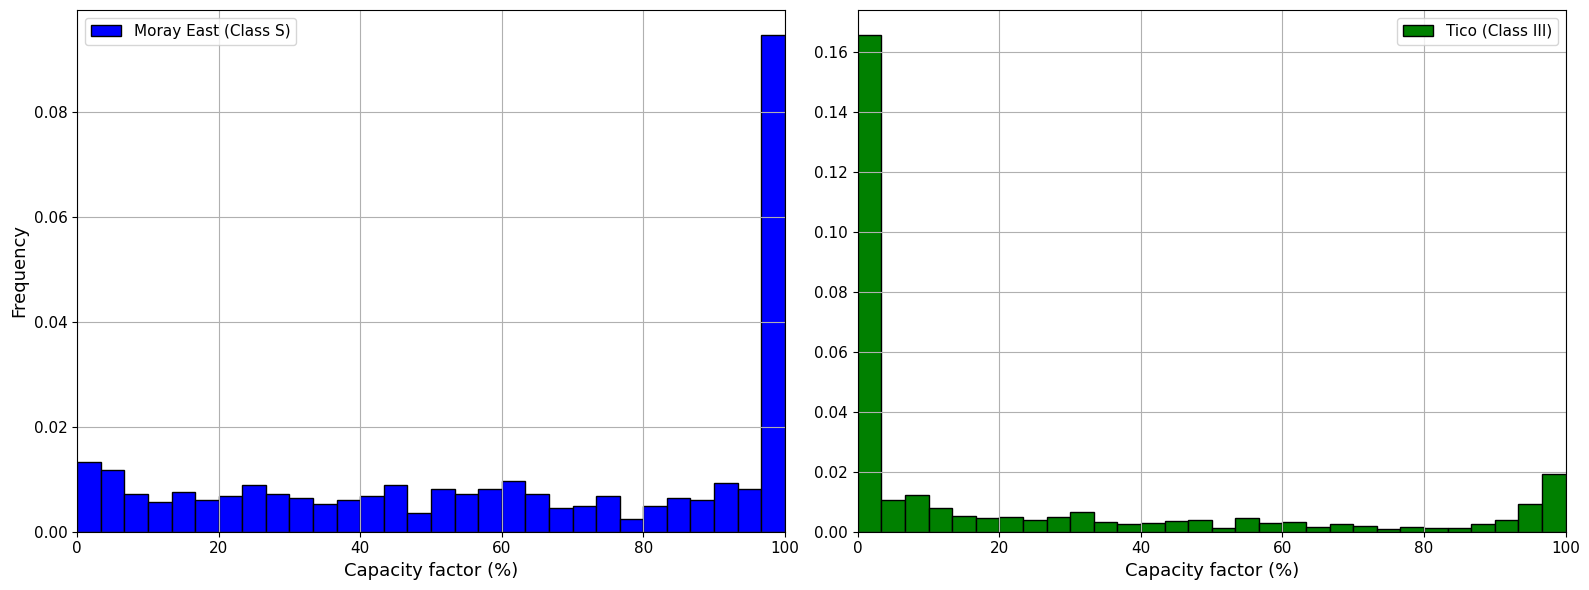

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (key, s) in zip(axes, sites.items()):
    counts, edges = capacity_factor_histogram_1d(witest_requires = ["pytest", "pytest-cov"]
docs_requires = ["sphinx", "setuptools-scm>=8.1.0"]
notebooks_requires = ["earthkit-data", "healpy", "conflator", "lxml"]

extras_require = {
    "test": test_requires,
    "docs": docs_requires,
    "notebooks": notebooks_requires,
    "all": install_requires + test_requires + docs_requires + notebooks_requires,
}nd_speeds[key], 30, s["lon"], s["lat"], s["iec_class"])
    ax.hist(edges[:-1] * 100, bins=edges * 100, weights=counts, density=True,
             color=colors[key], edgecolor="black", label=f"{s['name']} (Class {s['iec_class']})")
    ax.set_xlabel("Capacity factor (%)", fontsize=13)
    ax.set_xlim(0, 100)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)
    ax.grid(True)
axes[0].set_ylabel("Frequency", fontsize=13)
plt.tight_layout()
plt.savefig(out_path + "capacity_factor_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


### Annual Energy Production

Moray East: total AEP over January = 4413.7 MWh (1 turbine)
Tico: total AEP over January = 322.4 MWh (1 turbine)


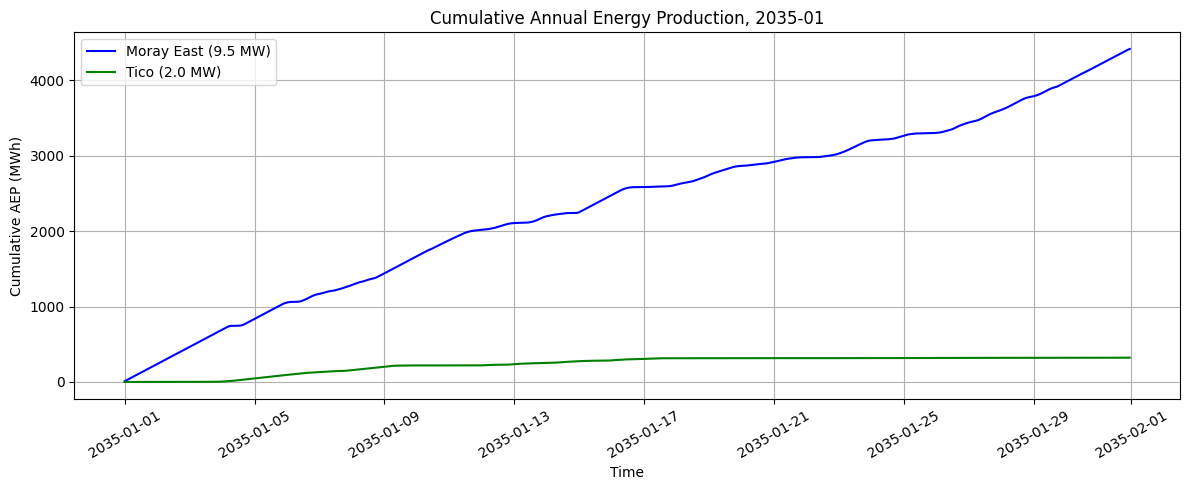

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
for key, s in sites.items():
    aep = annual_energy_production_wind(
        cf_data[key].squeeze(), rated_power=s["rated_power"], num_turbines=1
    )
    ax.plot(aep["time"], np.cumsum(aep.values),
             label=f"{s['name']} ({s['rated_power']} MW)", color=colors[key])
    print(f"{s['name']}: total AEP over January = {float(aep.sum()):.1f} MWh (1 turbine)")
ax.set_xlabel("Time"); ax.set_ylabel("Cumulative AEP (MWh)")
ax.set_title("Cumulative Annual Energy Production, 2035-01")
ax.legend(); ax.grid(True)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(out_path + "annual_energy_production.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Demand, Zaragoza

Cooling and Heating Degree Days from real daily mean/max/min
temperature.

In [16]:
temp = xr.open_dataset(data_path + "zaragoza_temp_203501.nc")
ZARAGOZA_LAT, ZARAGOZA_LON = float(temp["lat"]), float(temp["lon"])

t2_k = temp["2t"]
t2_k.attrs["units"] = "K"
t2_c = convert_temperature(t2_k, unit="C")

tm3d = as_grid(t2_c.resample(time="1D").mean(), ZARAGOZA_LAT, ZARAGOZA_LON)
tx3d = as_grid(t2_c.resample(time="1D").max(), ZARAGOZA_LAT, ZARAGOZA_LON)
tn3d = as_grid(t2_c.resample(time="1D").min(), ZARAGOZA_LAT, ZARAGOZA_LON)

cdd = cooling_degree_days(tm3d, tx3d, tn3d, base=22.0)
hdd = heating_degree_days(tm3d, tx3d, tn3d, base=15.5)

print(f"Zaragoza: total CDD={float(cdd['cdd'].sum()):.1f}, "
      f"total HDD={float(hdd['hdd'].sum()):.1f} (degree-days, January)")


Zaragoza: total CDD=0.0, total HDD=273.0 (degree-days, January)


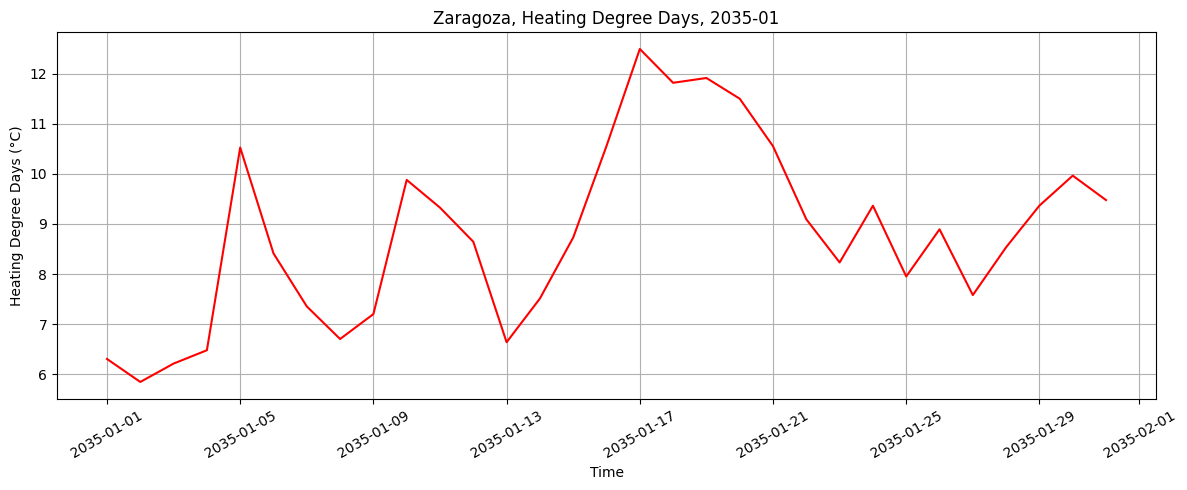

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
hdd_series = hdd["hdd"].squeeze()
ax.plot(hdd_series["time"], hdd_series, color="red")
ax.set_xlabel("Time"); ax.set_ylabel("Heating Degree Days (°C)")
ax.set_title("Zaragoza, Heating Degree Days, 2035-01")
ax.grid(True)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(out_path + "heating_degree_days.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Solar, Fuendetodos

PV potential for both January (winter) and July (summer), using each
month's own real temperature, radiation, and wind.

In [18]:
def compute_pv_potential(month, label):
    solar = xr.open_dataset(data_path + f"fuendetodos_solar_{month}.nc")
    fuen_lat, fuen_lon = float(solar["lat"]), float(solar["lon"])

    t2_k = solar["2t"]
    t2_k.attrs["units"] = "K"
    t2_c = convert_temperature(t2_k, unit="C")

    t2c_grid = as_grid(t2_c, fuen_lat, fuen_lon)
    g_grid = as_grid(solar["avg_sdswrf"], fuen_lat, fuen_lon)

    # Tico's wind for the same month, re-tagged with Fuendetodos's
    # coordinates so pv_pot can align it against the temperature and
    # radiation arrays (which are tagged with those coordinates too).
    tico_wind = xr.open_dataset(data_path + f"tico_wind_{month}.nc")
    u_for_fuen = as_grid(tico_wind["u"], fuen_lat, fuen_lon)
    v_for_fuen = as_grid(tico_wind["v"], fuen_lat, fuen_lon)
    ws_for_fuen = wind_speed(u_for_fuen, v_for_fuen)

    pvp = pv_pot(t2c_grid, g_grid, ws_for_fuen)
    print(f"Fuendetodos ({label}): mean PV potential = {float(pvp['pvp'].mean()):.4f}")
    return pvp["pvp"].squeeze(), t2_c, solar["avg_sdswrf"]


pvp_winter, t2c_winter, rad_winter = compute_pv_potential("203501", "winter")
pvp_summer, t2c_summer, rad_summer = compute_pv_potential("203507", "summer")


Fuendetodos (winter): mean PV potential = 0.1022
Fuendetodos (summer): mean PV potential = 0.3440


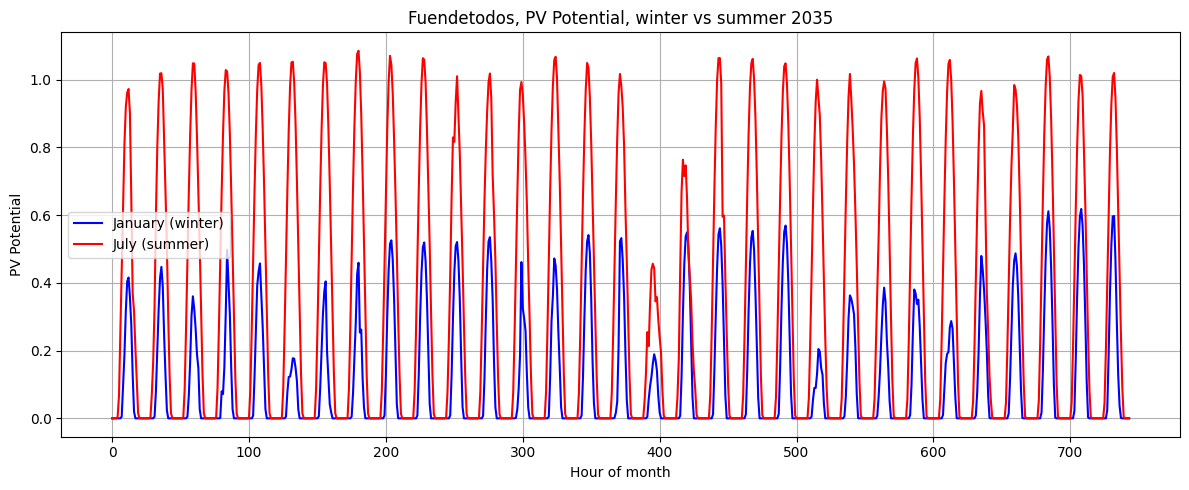

Mean PV potential - January: 0.1022, July: 0.3440


In [19]:
hours_winter = np.arange(len(pvp_winter))
hours_summer = np.arange(len(pvp_summer))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hours_winter, pvp_winter, label="January (winter)", color="blue")
ax.plot(hours_summer, pvp_summer, label="July (summer)", color="red")
ax.set_xlabel("Hour of month"); ax.set_ylabel("PV Potential")
ax.set_title("Fuendetodos, PV Potential, winter vs summer 2035")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig(out_path + "pv_potential_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean PV potential - January: {float(pvp_winter.mean()):.4f}, "
      f"July: {float(pvp_summer.mean()):.4f}")


### Temperature and radiation behind the seasonal contrast

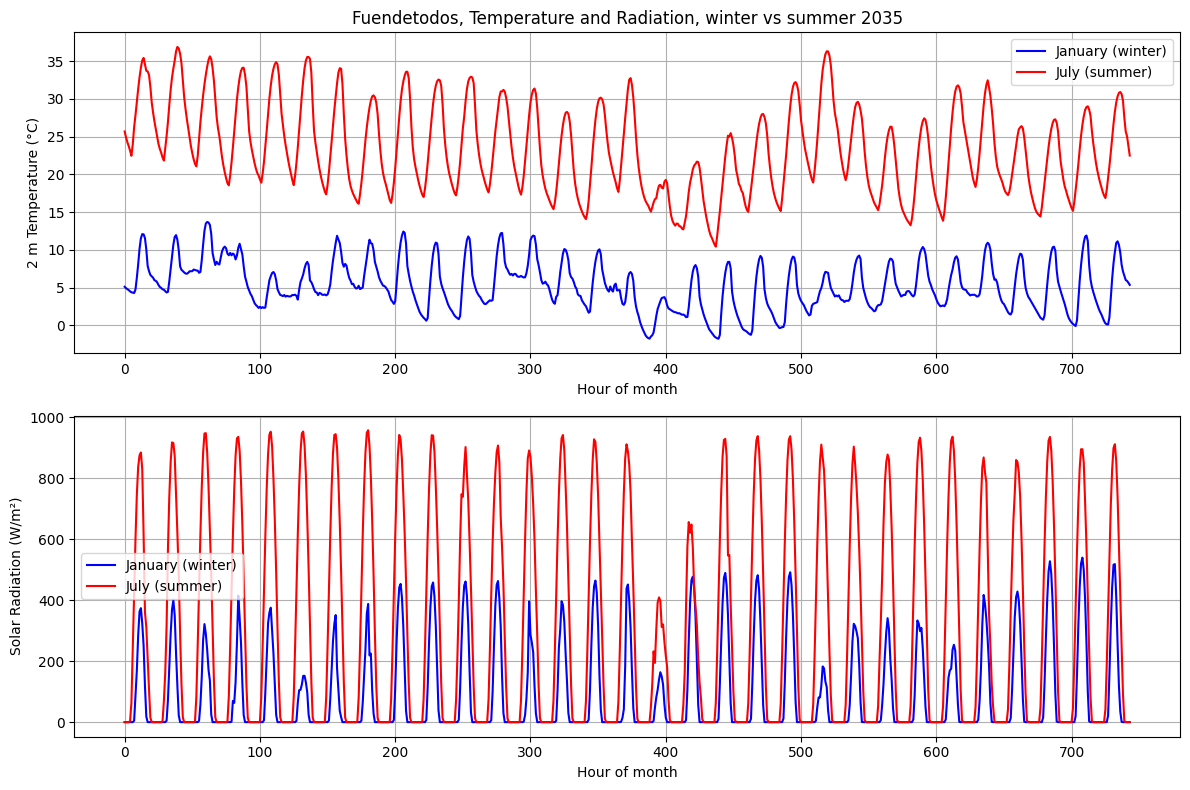

Mean radiation - January: 89.6 W/m², July: 313.5 W/m²


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(hours_winter, t2c_winter, label="January (winter)", color="blue")
axes[0].plot(hours_summer, t2c_summer, label="July (summer)", color="red")
axes[0].set_ylabel("2 m Temperature (°C)"); axes[0].set_xlabel("Hour of month")
axes[0].legend(); axes[0].grid(True)
axes[0].set_title("Fuendetodos, Temperature and Radiation, winter vs summer 2035")

axes[1].plot(hours_winter, rad_winter, label="January (winter)", color="blue")
axes[1].plot(hours_summer, rad_summer, label="July (summer)", color="red")
axes[1].set_ylabel("Solar Radiation (W/m²)"); axes[1].set_xlabel("Hour of month")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(out_path + "temp_radiation_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean radiation - January: {float(rad_winter.mean()):.1f} W/m², "
      f"July: {float(rad_summer.mean()):.1f} W/m²")


## Not covered here

Masking does not apply meaningfully to single-point data. Wind speed
anomalies require an external climatology reference not retrieved
here. OPA-based streaming histograms require the private `one_pass`
dependency, designed for the ClimateDT streaming workflow.

See the API Reference in the documentation for the full function
list.